# Energy-distance plots — WG1

Plots from the per-dataset `wg1_significant_tfs.tsv` tables, the cross-dataset wide / long roll-ups, and the per-dataset `targeting_outlier_table.csv`. Outputs (PDFs) land in [`../results/`](../results/).

Sections:
1. Bar plot — # TFs significant per dataset, two criteria
2. P-value cutoff sweep — per dataset (NC contamination)
3. Mean-distance scatter — pairwise across datasets
4. Distance heatmap — raw / rank / quantile normalization
5. Guide-outlier Jaccard — per-dataset outlier sets

Run with `Run → Run All`, or from the CLI:

```bash
uv run jupyter nbconvert --to notebook --execute --inplace scripts/edist_plots.ipynb
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.patches import Patch

# Resolve paths from the notebook's own location
HERE = Path.cwd()
EDIST = HERE if HERE.name == "edist" else HERE.parent
JAMB = EDIST.parents[2]
REPO = JAMB.parents[2]
RESULTS = EDIST / "results"

with open(REPO / "config/colors/production_TF-Perturb-seq.yaml") as f:
    CFG = yaml.safe_load(f)

# Map full dataset_id → short label, and short → bar color
SHORT = {
    "Hon_WTC11-cardiomyocyte-differentiation_TF-Perturb-seq": "HonCM",
    "Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq": "HuangfuDE",
    "Huangfu_HUES8-embryonic-stemcell-differentiation_TF-Perturb-seq": "HuangfuESC",
    "Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq": "GersbachHep",
    "Engreitz_WTC11-endothelial-cells_TF-Perturb-seq": "EngreitzEndo",
}
SHORT_TO_FULL = {v: k for k, v in SHORT.items()}
DATASET_ORDER = ["HonCM", "HuangfuDE", "HuangfuESC", "GersbachHep"]
COLORS = {s: CFG["dataset_colors"][SHORT_TO_FULL[s]] for s in DATASET_ORDER}

print("EDIST:", EDIST)
print("datasets in order:", DATASET_ORDER)


EDIST: /carter/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist
datasets in order: ['HonCM', 'HuangfuDE', 'HuangfuESC', 'GersbachHep']


## 1. Bar plot — # TFs significant per dataset

Two side-by-side bars per dataset: the calibration-robust `distance > NC max` count and the parametric `pval_mean < 0.05` count. The p-value bars are hatched where calibration is anti-conservative (NC false-positive rate > 10%).


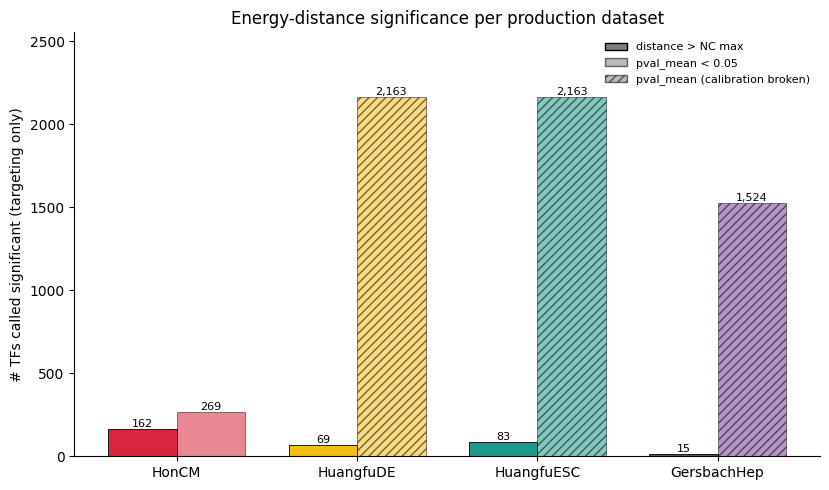

In [2]:
counts = pd.read_csv(RESULTS / "significant_tf_counts.tsv", sep="\t").set_index("dataset_id")
counts = counts.reindex([SHORT_TO_FULL[s] for s in DATASET_ORDER if SHORT_TO_FULL[s] in counts.index])

x = np.arange(len(counts))
w = 0.38
dist = counts["n_sig_distance_gt_NC_max"].to_numpy()
pval = counts["n_sig_pval_lt_0p05"].to_numpy()
colors = [COLORS[SHORT[d]] for d in counts.index]

fig, ax = plt.subplots(figsize=(1.6 * len(counts) + 2, 5))
b_dist = ax.bar(x - w / 2, dist, w, color=colors, edgecolor="black", linewidth=0.6)
b_pval = ax.bar(x + w / 2, pval, w, color=colors, edgecolor="black", linewidth=0.6, alpha=0.55)
for bar, state in zip(b_pval, counts["calibration_state"]):
    if state == "anti-conservative":
        bar.set_hatch("////")
for bar in list(b_dist) + list(b_pval):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([SHORT[d] for d in counts.index])
ax.set_ylabel("# TFs called significant (targeting only)")
ax.set_title("Energy-distance significance per production dataset")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(dist.max(), pval.max()) * 1.18)
ax.legend(handles=[
    Patch(facecolor="grey", edgecolor="black", label="distance > NC max"),
    Patch(facecolor="grey", edgecolor="black", alpha=0.55, label="pval_mean < 0.05"),
    Patch(facecolor="grey", edgecolor="black", alpha=0.55, hatch="////",
          label="pval_mean (calibration broken)"),
], loc="upper right", frameon=False, fontsize=8)

plt.tight_layout()
fig.savefig(RESULTS / "significant_tf_counts.pdf")
fig.savefig(RESULTS / "significant_tf_counts.png", dpi=200)
plt.show()


## 2. P-value cutoff sweep — per dataset

For each dataset, sweep the p-value cutoff and count the number of targets crossing it, split into **targeting** (blue) and **NC** (orange). Right panel: % NCs among the hits — a per-cutoff false-positive rate from the controls.

NCs here stand in for the OR-gene class on the original benchmark slide (production libraries don't carry an OR class).

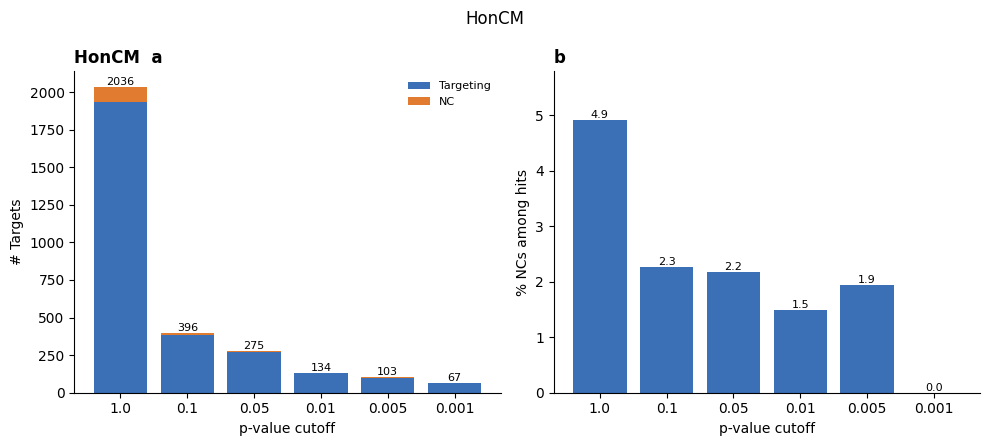

wrote /carter/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/cutoff_sweep_HonCM.pdf


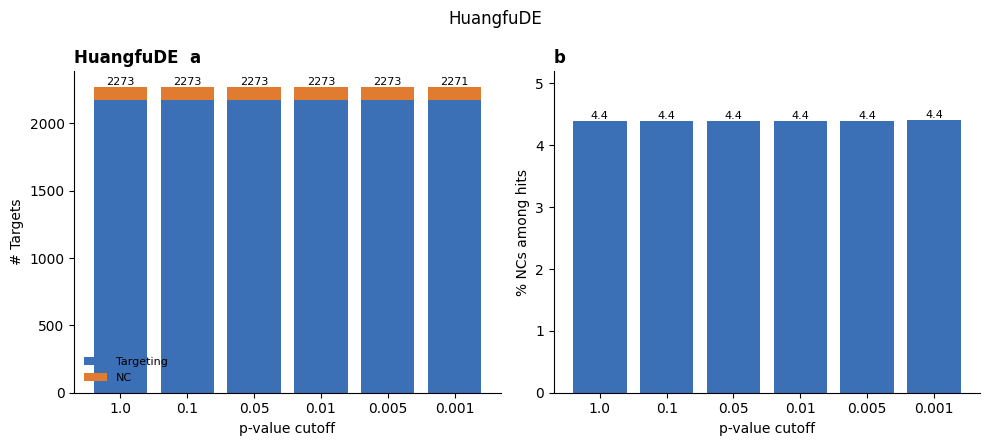

wrote /carter/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/cutoff_sweep_HuangfuDE.pdf


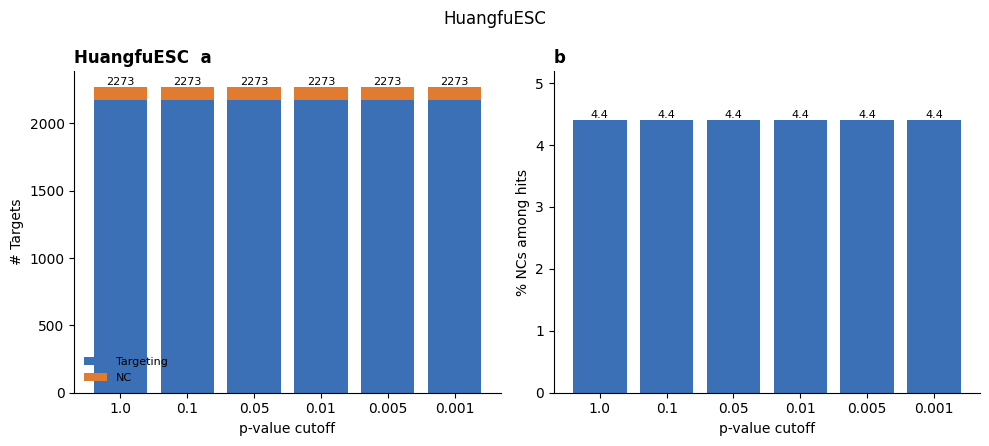

wrote /carter/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/cutoff_sweep_HuangfuESC.pdf


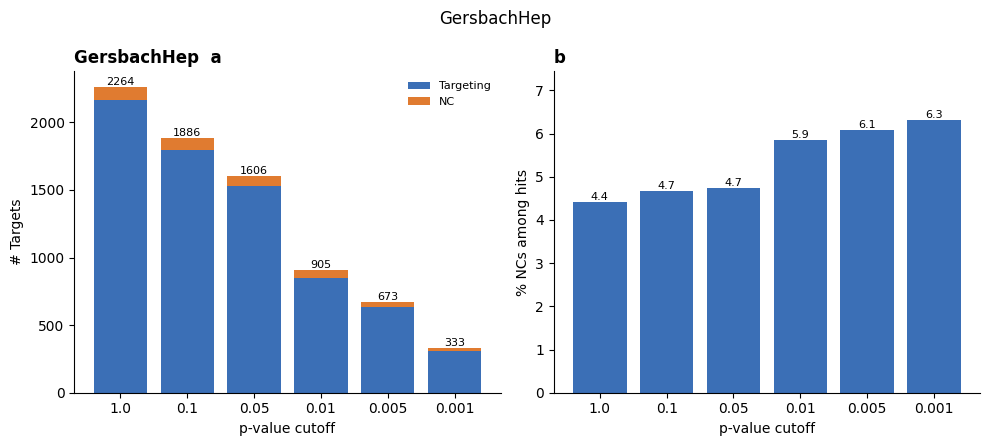

wrote /carter/users/aklie/projects/tf_perturb_seq/docs/jamborees/2026_UTSW/working_groups/wg1_data_qc/edist/results/cutoff_sweep_GersbachHep.pdf


In [3]:
CUTOFFS = [1.0, 0.1, 0.05, 0.01, 0.005, 0.001]

def cutoff_sweep_panel(df: pd.DataFrame, title: str, ax1, ax2) -> None:
    is_nc = df["type"] == "negative control"
    n_total = [(df["pval_mean"] < c).sum() for c in CUTOFFS]
    n_nc = [((df["pval_mean"] < c) & is_nc).sum() for c in CUTOFFS]
    n_target = [t - nc for t, nc in zip(n_total, n_nc)]
    pct_nc = [100 * nc / t if t else 0 for nc, t in zip(n_nc, n_total)]
    x = np.arange(len(CUTOFFS))

    ax1.bar(x, n_target, color="#3B6FB6", label="Targeting")
    ax1.bar(x, n_nc, bottom=n_target, color="#E07B30", label="NC")
    for xi, t in zip(x, n_total):
        ax1.text(xi, t, f"{t}", ha="center", va="bottom", fontsize=8)
    ax1.set_xticks(x); ax1.set_xticklabels([str(c) for c in CUTOFFS])
    ax1.set_xlabel("p-value cutoff"); ax1.set_ylabel("# Targets")
    ax1.set_title(f"{title}  a", loc="left", fontweight="bold")
    ax1.legend(frameon=False, fontsize=8)
    ax1.spines[["top", "right"]].set_visible(False)

    ax2.bar(x, pct_nc, color="#3B6FB6")
    for xi, p in zip(x, pct_nc):
        ax2.text(xi, p, f"{p:.1f}", ha="center", va="bottom", fontsize=8)
    ax2.set_xticks(x); ax2.set_xticklabels([str(c) for c in CUTOFFS])
    ax2.set_xlabel("p-value cutoff"); ax2.set_ylabel("% NCs among hits")
    ax2.set_title("b", loc="left", fontweight="bold")
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim(0, max(max(pct_nc) * 1.18, 5))

for short in DATASET_ORDER:
    full = SHORT_TO_FULL[short]
    p = JAMB / "data" / full / "energy_distance" / "wg1_significant_tfs.tsv"
    if not p.is_file():
        print(f"skip {short}: {p} not found")
        continue
    df = pd.read_csv(p, sep="\t")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
    cutoff_sweep_panel(df, short, ax1, ax2)
    fig.suptitle(short)
    plt.tight_layout()
    out = RESULTS / f"cutoff_sweep_{short}.pdf"
    fig.savefig(out)
    plt.show()
    print(f"wrote {out}")

## 3. Mean-distance scatter — pairwise across datasets

Each dot is a target. Color by type (NC / PC / targeting). The headline pair is **Hon CM vs Gersbach Hep**; an all-pairs grid follows.

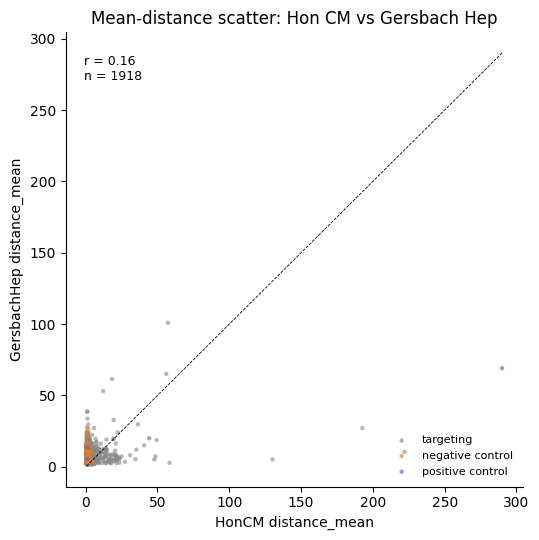

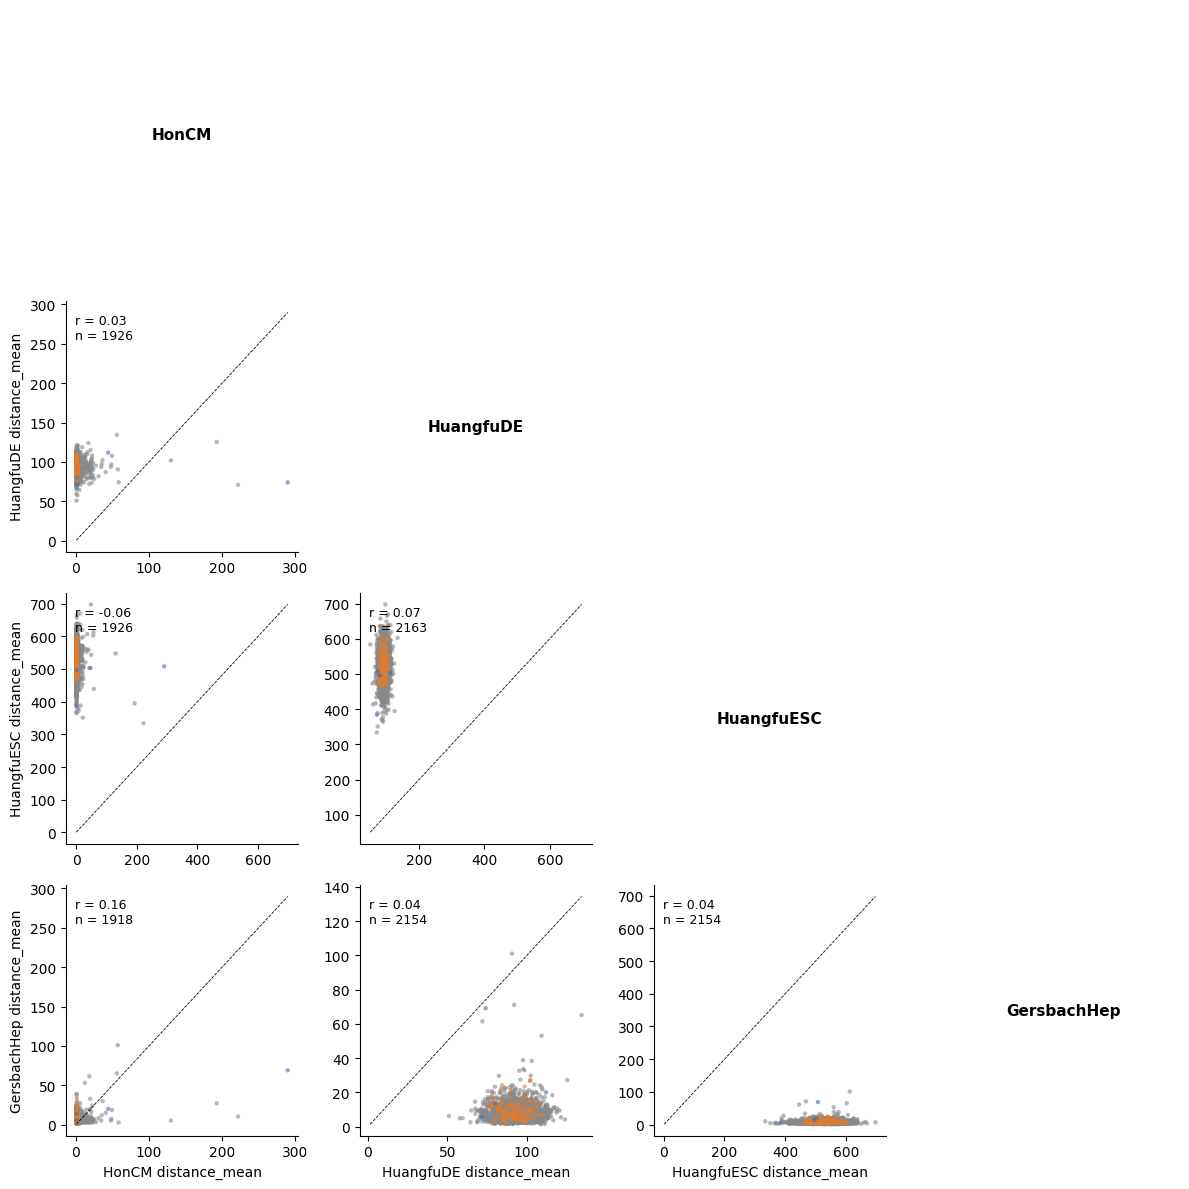

In [4]:
long = pd.read_csv(RESULTS / "per_target_long.tsv", sep="\t")

def scatter_pair(x_short: str, y_short: str, ax) -> None:
    px = long[long["dataset_short"] == x_short].set_index("target_id")["distance_mean"]
    py = long[long["dataset_short"] == y_short].set_index("target_id")["distance_mean"]
    typ = long[long["dataset_short"] == x_short].set_index("target_id")["type"]
    common = px.index.intersection(py.index)
    px, py, typ = px.loc[common], py.loc[common], typ.loc[common]
    type_colors = {"targeting": "#888888", "negative control": "#E07B30", "positive control": "#3B6FB6"}
    for t, c in type_colors.items():
        m = typ == t
        ax.scatter(px[m], py[m], s=10, c=c, alpha=0.6, edgecolors="none", label=t)
    lo = min(px.min(), py.min())
    hi = max(px.max(), py.max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.6, linestyle="--")
    ax.set_xlabel(f"{x_short} distance_mean")
    ax.set_ylabel(f"{y_short} distance_mean")
    ax.spines[["top", "right"]].set_visible(False)
    # Pearson correlation on targeting only
    m = typ == "targeting"
    r = np.corrcoef(px[m], py[m])[0, 1]
    ax.text(0.04, 0.95, f"r = {r:.2f}\nn = {m.sum()}", transform=ax.transAxes,
            va="top", fontsize=9)

# Headline scatter
fig, ax = plt.subplots(figsize=(5.5, 5.5))
scatter_pair("HonCM", "GersbachHep", ax)
ax.set_title("Mean-distance scatter: Hon CM vs Gersbach Hep")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
fig.savefig(RESULTS / "distance_scatter_HonCM_vs_GersbachHep.pdf")
plt.show()

# All-pairs grid (lower triangle)
n = len(DATASET_ORDER)
fig, axes = plt.subplots(n, n, figsize=(3.0 * n, 3.0 * n))
for i, ds_y in enumerate(DATASET_ORDER):
    for j, ds_x in enumerate(DATASET_ORDER):
        ax = axes[i, j]
        if i == j:
            ax.text(0.5, 0.5, ds_x, ha="center", va="center", fontsize=11,
                    transform=ax.transAxes, fontweight="bold")
            ax.set_xticks([]); ax.set_yticks([])
            ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
        elif i > j:
            scatter_pair(ds_x, ds_y, ax)
            ax.set_title("")
            if i != n - 1: ax.set_xlabel("")
            if j != 0: ax.set_ylabel("")
        else:
            ax.set_visible(False)
plt.tight_layout()
fig.savefig(RESULTS / "distance_scatter_all_pairs.pdf")
plt.show()


## 4. Distance heatmap — raw / rank / quantile

Targets × datasets, restricted to targets observed in all 4 datasets and to `type == "targeting"`. Three panels:

- **raw**: `distance_mean` as-is (color scale dominated by Huangfu's 100-1000× larger values — see calibration caveat in [README](../README.md))
- **rank**: per-column rank, scaled to [0, 1]
- **quantile**: each column mapped onto the average sorted profile (proper quantile normalization)

Rows are clustered (hierarchical, on rank-normalized values).


heatmap matrix: 1918 targets × 4 datasets


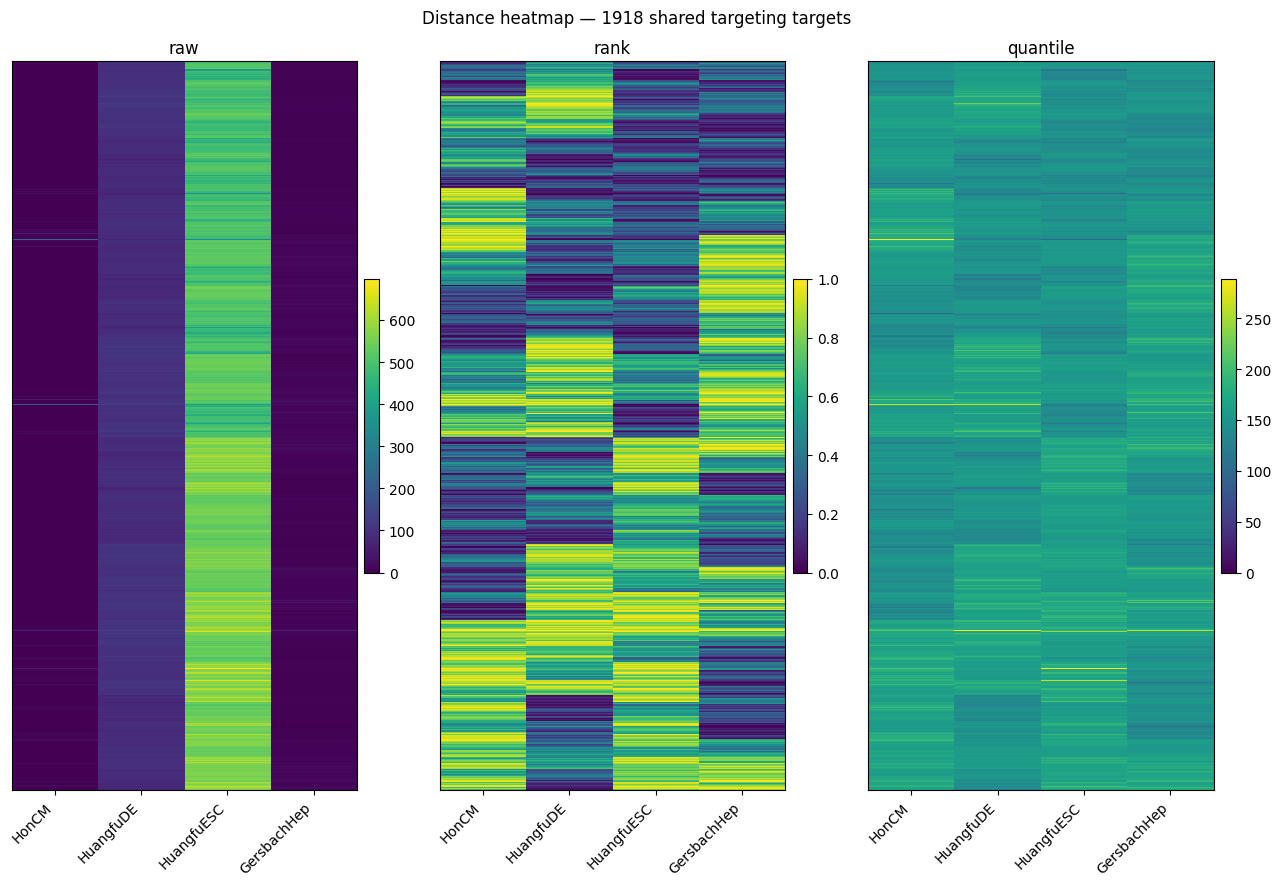

In [5]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

wide = pd.read_csv(RESULTS / "per_target_wide.tsv", sep="\t")
ds_cols = [f"{s}_distance_mean" for s in DATASET_ORDER]
type_cols = [f"{s}_type" for s in DATASET_ORDER]

# Restrict to targets typed "targeting" in every dataset
mask = wide[type_cols].eq("targeting").all(axis=1) & wide[ds_cols].notna().all(axis=1)
mat = wide.loc[mask, ["target_id", "gene_symbol"] + ds_cols].copy()
mat.columns = ["target_id", "gene_symbol"] + DATASET_ORDER
mat = mat.set_index("gene_symbol")[DATASET_ORDER]
print(f"heatmap matrix: {mat.shape[0]} targets × {mat.shape[1]} datasets")

def rank_normalize(df: pd.DataFrame) -> pd.DataFrame:
    return df.rank(axis=0, method="average") / len(df)

def quantile_normalize(df: pd.DataFrame) -> pd.DataFrame:
    # Match each column's empirical distribution to the average of all columns' sorted values
    sorted_each = pd.DataFrame(np.sort(df.values, axis=0), columns=df.columns)
    ref = sorted_each.mean(axis=1).values
    rank = df.rank(axis=0, method="min").astype(int) - 1
    out = pd.DataFrame(ref[rank.values], index=df.index, columns=df.columns)
    return out

variants = {"raw": mat, "rank": rank_normalize(mat), "quantile": quantile_normalize(mat)}

# Cluster row order using rank-normalized values (stable across datasets)
row_link = linkage(pdist(variants["rank"].values, metric="euclidean"), method="average")
row_order = leaves_list(row_link)
for k in variants:
    variants[k] = variants[k].iloc[row_order]

fig, axes = plt.subplots(1, 3, figsize=(13, 9))
for ax, (label, m) in zip(axes, variants.items()):
    vmax = m.values.max()
    im = ax.imshow(m.values, aspect="auto", cmap="viridis",
                   vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_xticks(range(m.shape[1]))
    ax.set_xticklabels(m.columns, rotation=45, ha="right")
    ax.set_yticks([])
    ax.set_title(label)
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle(f"Distance heatmap — {mat.shape[0]} shared targeting targets")
plt.tight_layout()
fig.savefig(RESULTS / "distance_heatmap.pdf")
plt.show()


## 5. Guide-outlier Jaccard — per-dataset outlier sets

Outlier gRNAs are guides with `pval_outlier < 0.05` in each dataset's `targeting_outlier_table.csv`. Pairwise Jaccard between the resulting per-dataset sets — lighter = more shared outliers.

Note: Gersbach Hep's run does not return meaningful outlier p-values (all 1.0), so its row/column is all-zero. Flagging in the WG1 ED discussion.


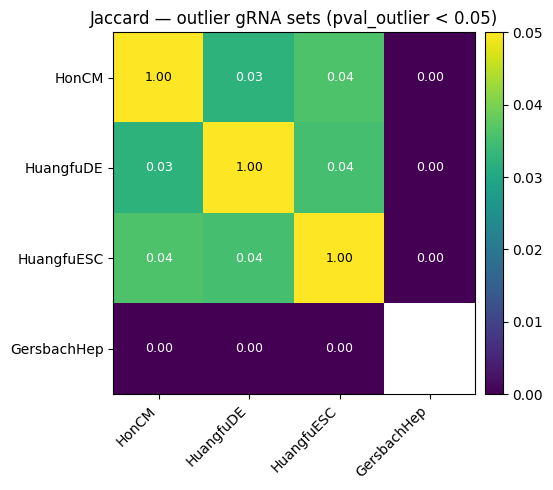


Outlier set sizes:
             n_total_grnas  n_outlier_grnas
dataset                                    
HonCM                13534              910
HuangfuDE            13534              460
HuangfuESC           13534             1270
GersbachHep          13457                0


In [6]:
jac = pd.read_csv(RESULTS / "guide_outlier_jaccard.tsv", sep="\t", index_col=0)
sizes = jac[["n_total_grnas", "n_outlier_grnas"]]
M = jac.drop(columns=["n_total_grnas", "n_outlier_grnas"]).reindex(
    index=DATASET_ORDER, columns=DATASET_ORDER,
).astype(float)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M.values, cmap="viridis", vmin=0, vmax=max(M.values[~np.eye(len(M), dtype=bool)].max(), 0.05))
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=45, ha="right")
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index)
for i in range(len(M)):
    for j in range(len(M)):
        v = M.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black", fontsize=9)

ax.set_title("Jaccard — outlier gRNA sets (pval_outlier < 0.05)")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
fig.savefig(RESULTS / "guide_outlier_jaccard_heatmap.pdf")
plt.show()

print()
print("Outlier set sizes:")
print(sizes.to_string())
